In [2]:
!pip3 install rebound

  Using cached rebound-4.6.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
Using cached rebound-4.6.0-cp311-cp311-win_amd64.whl (316 kB)


In [3]:
# Aquí las Librerías que voy creyendo necesarias
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb


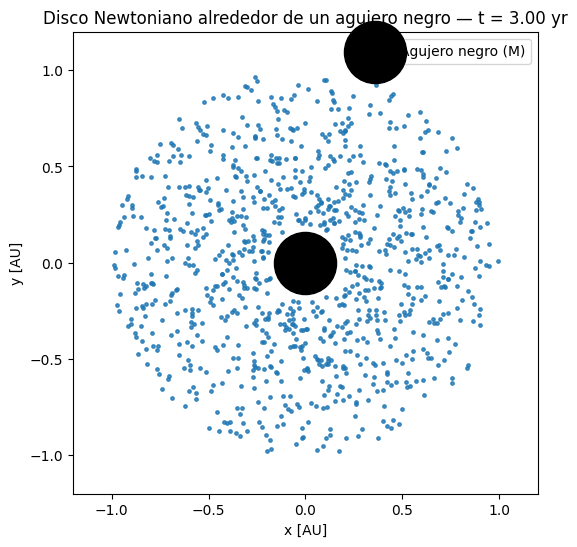

In [16]:
# Ejemplo: disco Newtoniano alrededor de un agujero negro (visualización + atracción)
from IPython.display import clear_output, display

# Crear simulación
sim = rb.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.G = 1.0
# Añadir agujero negro (masa central, tratado Newtonianamente)
M = 1.0
sim.add(m=M)  # objeto central: agujero negro (representado por masa)

# Añadir partículas test en un disco (distribución azimutal aleatoria)
N = 1000
rmin, rmax = 0.2, 1.0  # evitamos r muy pequeñas para representar un 'horizon' visual
rs = np.random.uniform(rmin, rmax, N)
thetas = np.random.uniform(0, 2*np.pi, N)
for r, th in zip(rs, thetas):
    x = r * np.cos(th)
    y = r * np.sin(th)
    v = np.sqrt(sim.G * M / r)  # velocidad circular (aprox Newtoniana)
    vx = -v * np.sin(th)
    vy =  v * np.cos(th)
    sim.add(x=x, y=y, vx=vx, vy=vy, m=0)  # partículas test

sim.move_to_com()

# Integrar y mostrar snapshots del disco con el agujero negro visible
times = np.linspace(0, 3, 10)
fig, ax = plt.subplots(figsize=(6,6))
for t in times:
    sim.integrate(t)
    pts = np.array([[p.x, p.y] for p in sim.particles[1:]])
    ax.clear()
    # dibujar el agujero negro (punto negro grande)
    ax.scatter(0, 0, s=1000, c='k', marker='o', label='Agujero negro (M)')
    # partículas del disco
    if pts.size > 0:
        ax.scatter(pts[:,0], pts[:,1], s=6, c='C0', alpha=0.8)
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel('x [AU]'); ax.set_ylabel('y [AU]')
    ax.set_title(f'Disco Newtoniano alrededor de un agujero negro — t = {t:.2f} yr')
    ax.legend(loc='upper right')
    display(fig)
    clear_output(wait=True)

# Observación: la dinámica aquí es puramente Newtoniana; el agujero negro se representa como la masa central visible.
# Para incluir efectos relativistas (precesión, ISCO, etc.) habría que añadir correcciones efectivas al potencial o usar integradores relativistas.